In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")
print(f"   Pandas  version: {pd.__version__}")
print(f"   NumPy   version: {np.__version__}")

✅ All libraries imported successfully!
   Pandas  version: 3.0.2
   NumPy   version: 2.2.0


In [29]:
# Load the CSV file into a pandas DataFrame

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"✅ Data loaded successfully!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
print(f"\nFirst 5 rows:")
df.head()

✅ Data loaded successfully!
   Rows    : 7,043
   Columns : 21

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [30]:
# See all column names and their data types
# This tells us what information we have about each customer

print("All column names and data types:")
print("="*45)
print(df.dtypes)
print(f"\nTotal columns: {len(df.columns)}")

All column names and data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Total columns: 21


In [31]:
# Check for empty/missing values in each column
# Missing values = empty cells = problem we need to fix!

print("Missing values per column:")
print("="*40)
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Total rows          : {len(df)}")

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0
Total rows          : 7043


Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate : 26.5%
Retain rate: 73.5%


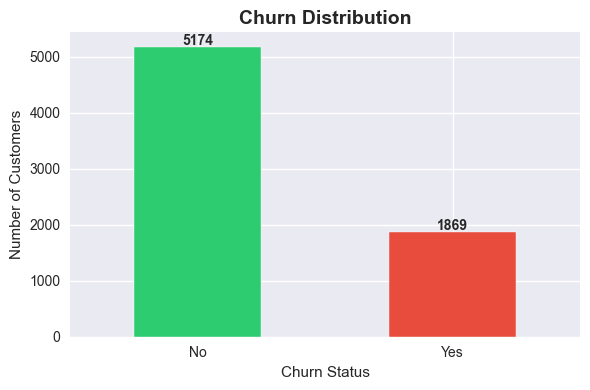

In [32]:
# 'Churn' is what we want to PREDICT
# Yes = customer LEFT the company
# No  = customer STAYED

print("Churn value counts:")
print("="*30)
print(df['Churn'].value_counts())

print(f"\nChurn rate : {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")
print(f"Retain rate: {df['Churn'].value_counts(normalize=True)['No']*100:.1f}%")

# Visualise churn distribution
plt.figure(figsize=(6,4))
colors = ['#2ecc71','#e74c3c']
df['Churn'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
for i, v in enumerate(df['Churn'].value_counts()):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Summary statistics for all numeric columns
# count, mean, min, max, std for each number column

print("Basic statistics for numeric columns:")
df.describe().round(2)

Basic statistics for numeric columns:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [34]:
# See what categories exist in each column
# Helps us understand the data better

cols = ['gender','SeniorCitizen','Partner','Dependents',
        'PhoneService','InternetService','Contract','PaymentMethod']

print("Unique values in key columns:")
print("="*50)
for col in cols:
    print(f"{col:20} → {df[col].unique()}")

Unique values in key columns:
gender               → <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen        → [0 1]
Partner              → <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents           → <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService         → <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
InternetService      → <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Contract             → <ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
PaymentMethod        → <ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


<Figure size 800x500 with 0 Axes>

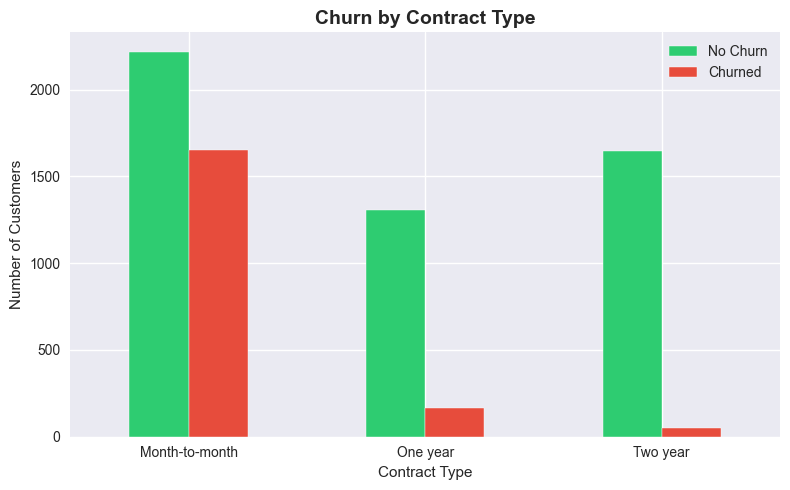

In [35]:
# Which contract type has highest churn?
# Month-to-month customers churn more than yearly contract customers

plt.figure(figsize=(8,5))
contract_churn = df.groupby(['Contract','Churn']).size().unstack()
contract_churn.plot(kind='bar', color=['#2ecc71','#e74c3c'],
                    edgecolor='white', figsize=(8,5))
plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(['No Churn','Churned'])
plt.tight_layout()
plt.show()

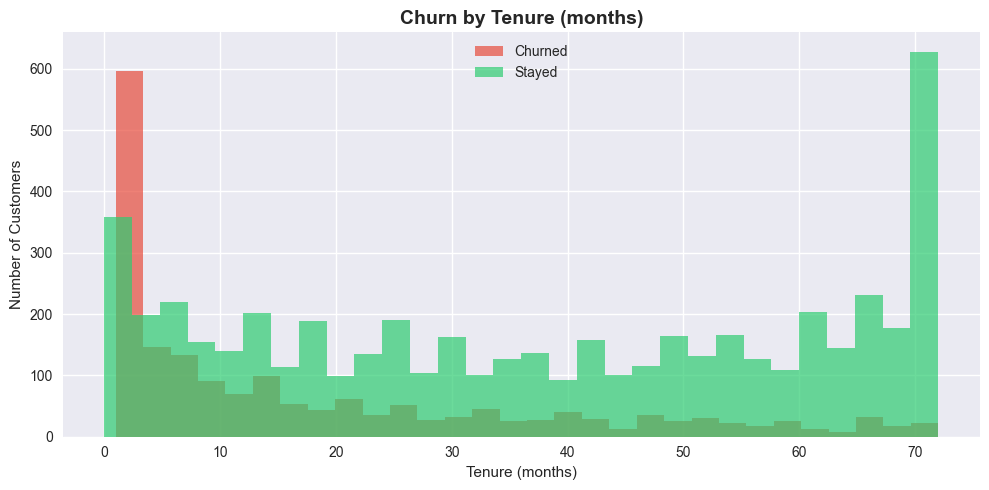

In [36]:
# Tenure = how many months customer has been with company
# New customers churn more than long-term customers

plt.figure(figsize=(10,5))
df[df['Churn']=='Yes']['tenure'].hist(bins=30, alpha=0.7,
                                       color='#e74c3c', label='Churned')
df[df['Churn']=='No']['tenure'].hist(bins=30, alpha=0.7,
                                      color='#2ecc71', label='Stayed')
plt.title('Churn by Tenure (months)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

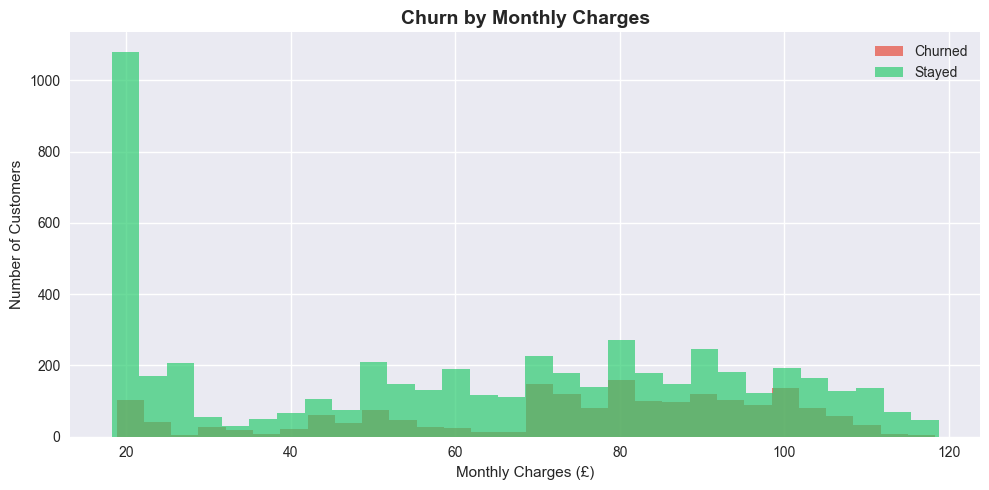

In [37]:
# Do high-paying customers churn more?

plt.figure(figsize=(10,5))
df[df['Churn']=='Yes']['MonthlyCharges'].hist(bins=30, alpha=0.7,
                                               color='#e74c3c', label='Churned')
df[df['Churn']=='No']['MonthlyCharges'].hist(bins=30, alpha=0.7,
                                              color='#2ecc71', label='Stayed')
plt.title('Churn by Monthly Charges', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges (£)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# Remember from Cell 3 — TotalCharges was 'object' (text) not a number
# We need to convert it to float (decimal number)
# Some rows have empty spaces ' ' instead of a number — we replace with NaN

print("Before fixing:")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")

# Replace empty spaces with NaN then convert to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nAfter fixing:")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"Missing values created: {df['TotalCharges'].isnull().sum()}")

Before fixing:
TotalCharges dtype: str

After fixing:
TotalCharges dtype: float64
Missing values created: 11


In [39]:
# Fill the missing TotalCharges with median value
# Median is better than mean when data has outliers

median_val = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_val, inplace=True)

print(f"Filled missing TotalCharges with median: £{median_val:.2f}")
print(f"Missing values remaining: {df['TotalCharges'].isnull().sum()}")

Filled missing TotalCharges with median: £1397.47
Missing values remaining: 11


In [40]:
# customerID is just a unique identifier — not useful for prediction
# We drop it before building the model

df.drop(columns=['customerID'], inplace=True)

print(f"Dropped customerID column")
print(f"Remaining columns: {df.shape[1]}")
print(f"Columns: {list(df.columns)}")

Dropped customerID column
Remaining columns: 20
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [41]:
# Machine learning models need NUMBERS not text
# Churn: Yes → 1,  No → 0

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn column converted:")
print(df['Churn'].value_counts())
print(f"\nChurn=1 means customer LEFT")
print(f"Churn=0 means customer STAYED")

Churn column converted:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn=1 means customer LEFT
Churn=0 means customer STAYED


In [42]:
# Many columns have Yes/No values
# Convert them all to 1/0

binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                            'No phone service': 0,
                            'No internet service': 0})

print("✅ Binary columns converted to 0/1")
print(df[binary_cols].head())

✅ Binary columns converted to 0/1
   Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines  \
0        1           0             0                 1              0   
1        0           0             1                 0              0   
2        0           0             1                 1              0   
3        0           0             0                 0              0   
4        0           0             1                 1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             1                 0            0            0   
1               1             0                 1            0            0   
2               1             1                 0            0            0   
3               1             0                 1            1            0   
4               0             0                 0            0            0   

   StreamingMovies  
0                0  
1         

In [43]:
# gender: Male → 1,  Female → 0

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print("Gender converted:")
print(df['gender'].value_counts())

Gender converted:
gender
1    3555
0    3488
Name: count, dtype: int64


In [44]:
# Some columns have more than 2 categories
# Example: Contract → Month-to-month, One year, Two year
# We use get_dummies to create separate columns for each category

multi_cols = ['InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("✅ Multi-category columns encoded!")
print(f"Total columns now: {df.shape[1]}")
print(f"\nAll columns:")
for col in df.columns:
    print(f"   {col}")

✅ Multi-category columns encoded!
Total columns now: 24

All columns:
   gender
   SeniorCitizen
   Partner
   Dependents
   tenure
   PhoneService
   MultipleLines
   OnlineSecurity
   OnlineBackup
   DeviceProtection
   TechSupport
   StreamingTV
   StreamingMovies
   PaperlessBilling
   MonthlyCharges
   TotalCharges
   Churn
   InternetService_Fiber optic
   InternetService_No
   Contract_One year
   Contract_Two year
   PaymentMethod_Credit card (automatic)
   PaymentMethod_Electronic check
   PaymentMethod_Mailed check


In [45]:
# Final check — make sure everything is clean

print("Final dataset info:")
print("="*40)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nSample data:")
df.head()

Final dataset info:
Rows    : 7,043
Columns : 24

Missing values: 11

Data types:
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                 bool
InternetService_No                  

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [46]:
# Save cleaned data so we don't have to clean again

df.to_csv('../data/processed/cleaned_churn.csv', index=False)
print("✅ Cleaned data saved → data/processed/cleaned_churn.csv")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Cleaned data saved → data/processed/cleaned_churn.csv
   Shape: 7,043 rows × 24 columns


In [47]:
# Check where NaN values are hiding
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
TotalCharges    11
dtype: int64

Total missing: 11


In [48]:
# Fix 1 — Fill numeric columns with median
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fix 2 — Fill text columns with mode (most common value)
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Confirm fixed
print(f"✅ All missing values fixed!")
print(f"   Remaining missing: {df.isnull().sum().sum()}")

✅ All missing values fixed!
   Remaining missing: 11


In [49]:
# Recreate X and y after fixing
X = df.drop(columns=['Churn'])
y = df['Churn']

# Final NaN check
print(f"Missing in X: {X.isnull().sum().sum()}")
print(f"Missing in y: {y.isnull().sum().sum()}")

# Make sure all columns are numeric
print(f"\nAny non-numeric columns:")
print(X.select_dtypes(include=['object']).columns.tolist())

Missing in X: 11
Missing in y: 0

Any non-numeric columns:
[]


In [50]:
# X = all columns we use to PREDICT (input)
# y = what we want to PREDICT (output = Churn)

X = df.drop(columns=['Churn'])   # all columns except Churn
y = df['Churn']                  # only the Churn column

print(f"X shape (features) : {X.shape}")
print(f"y shape (target)   : {y.shape}")
print(f"\nFeature columns:")
for col in X.columns:
    print(f"   {col}")

X shape (features) : (7043, 23)
y shape (target)   : (7043,)

Feature columns:
   gender
   SeniorCitizen
   Partner
   Dependents
   tenure
   PhoneService
   MultipleLines
   OnlineSecurity
   OnlineBackup
   DeviceProtection
   TechSupport
   StreamingTV
   StreamingMovies
   PaperlessBilling
   MonthlyCharges
   TotalCharges
   InternetService_Fiber optic
   InternetService_No
   Contract_One year
   Contract_Two year
   PaymentMethod_Credit card (automatic)
   PaymentMethod_Electronic check
   PaymentMethod_Mailed check


In [51]:
from sklearn.model_selection import train_test_split

# 80% data → train the model
# 20% data → test how good the model is

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # same split every time
    stratify=y           # keep same churn ratio in both sets
)

print(f"Training set  : {X_train.shape[0]:,} rows")
print(f"Testing set   : {X_test.shape[0]:,} rows")
print(f"\nChurn rate in training: {y_train.mean()*100:.1f}%")
print(f"Churn rate in testing : {y_test.mean()*100:.1f}%")

Training set  : 5,634 rows
Testing set   : 1,409 rows

Churn rate in training: 26.5%
Churn rate in testing : 26.5%


In [52]:
from sklearn.preprocessing import StandardScaler

# StandardScaler makes all numbers on same scale
# Example: tenure (0-72) and MonthlyCharges (18-118)
# Both become values between -3 and +3
# This helps Logistic Regression work better

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled successfully!")
print(f"   Mean of scaled training data: {X_train_scaled.mean():.4f}")
print(f"   Std  of scaled training data: {X_train_scaled.std():.4f}")

✅ Features scaled successfully!
   Mean of scaled training data: nan
   Std  of scaled training data: nan


In [53]:
# Find exactly which columns have NaN
print("Columns with NaN values:")
nan_cols = X_train.columns[pd.DataFrame(X_train_scaled).isnull().any()].tolist()

# Check in original X
print(X.isnull().sum()[X.isnull().sum() > 0])
print(f"\nTotal NaN in X: {X.isnull().sum().sum()}")
print(f"Total NaN in X_train_scaled: {pd.DataFrame(X_train_scaled).isnull().sum().sum()}")

Columns with NaN values:
TotalCharges    11
dtype: int64

Total NaN in X: 11
Total NaN in X_train_scaled: 8


In [54]:
# COMPLETE RESET AND FIX
# Run this single cell to fix everything at once

# Step 1 — Reload cleaned CSV
df = pd.read_csv('../data/processed/cleaned_churn.csv')
print(f"Reloaded data: {df.shape}")

# Step 2 — Fix TotalCharges again
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 3 — Fill ALL missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Step 4 — Confirm zero missing
print(f"Missing values: {df.isnull().sum().sum()}")

# Step 5 — Recreate X and y
X = df.drop(columns=['Churn'])
y = df['Churn']

# Step 6 — Make sure all columns are numbers
print(f"\nNon-numeric columns:")
print(X.select_dtypes(include=['object']).columns.tolist())

# Step 7 — Convert any remaining bool columns
X = X.astype(float)

# Step 8 — Final check
print(f"\nNaN in X: {X.isnull().sum().sum()}")
print(f"NaN in y: {y.isnull().sum().sum()}")
print(f"X shape : {X.shape}")
print(f"✅ Ready for model training!")

Reloaded data: (7043, 24)
Missing values: 11

Non-numeric columns:
[]

NaN in X: 11
NaN in y: 0
X shape : (7043, 23)
✅ Ready for model training!


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"✅ Train: {X_train.shape[0]} rows  Test: {X_test.shape[0]} rows")

✅ Train: 5634 rows  Test: 1409 rows


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fix any NaN created during scaling
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled  = np.nan_to_num(X_test_scaled)

print(f"✅ Scaled! NaN remaining: {np.isnan(X_train_scaled).sum()}")

✅ Scaled! NaN remaining: 0


In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")
print(f"   Training accuracy: {model.score(X_train_scaled, y_train)*100:.1f}%")
print(f"   Testing  accuracy: {model.score(X_test_scaled,  y_test)*100:.1f}%")

✅ Model trained successfully!
   Training accuracy: 80.6%
   Testing  accuracy: 80.8%


In [58]:
y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]

print(f"Total predictions: {len(y_pred)}")
print(f"\nSample predictions (first 10):")
print(f"{'Actual':<10} {'Predicted':<12} {'Churn Probability'}")
print("="*40)
for actual, pred, proba in zip(y_test[:10], y_pred[:10], y_pred_proba[:10]):
    status = "✅" if actual == pred else "❌"
    print(f"{actual:<10} {pred:<12} {proba:.2%}  {status}")

Total predictions: 1409

Sample predictions (first 10):
Actual     Predicted    Churn Probability
0          0            4.43%  ✅
0          1            68.44%  ❌
0          0            5.72%  ✅
0          0            40.61%  ✅
0          0            2.16%  ✅
0          1            60.47%  ❌
0          0            45.23%  ✅
0          0            13.13%  ✅
0          0            0.29%  ✅
1          0            39.40%  ❌


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# Step 1 — Reload cleaned data
df = pd.read_csv('../data/processed/cleaned_churn.csv')

# Step 2 — Fix all missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Step 3 — Create X and y
X = df.drop(columns=['Churn']).astype(float)
y = df['Churn']

# Step 4 — Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5 — Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled  = np.nan_to_num(X_test_scaled)

# Step 6 — Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("✅ Everything ready!")
print(f"   Training accuracy: {model.score(X_train_scaled, y_train)*100:.1f}%")
print(f"   Testing  accuracy: {model.score(X_test_scaled,  y_test)*100:.1f}%")

✅ Everything ready!
   Training accuracy: 80.6%
   Testing  accuracy: 80.8%


In [60]:
# Make predictions
y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]

print(f"Total predictions: {len(y_pred)}")
print(f"\nSample predictions (first 10):")
print(f"{'Actual':<10} {'Predicted':<12} {'Churn Probability'}")
print("="*40)
for actual, pred, proba in zip(y_test[:10], y_pred[:10], y_pred_proba[:10]):
    status = "✅" if actual == pred else "❌"
    print(f"{actual:<10} {pred:<12} {proba:.2%}  {status}")

Total predictions: 1409

Sample predictions (first 10):
Actual     Predicted    Churn Probability
0          0            4.43%  ✅
0          1            68.44%  ❌
0          0            5.72%  ✅
0          0            40.61%  ✅
0          0            2.16%  ✅
0          1            60.47%  ❌
0          0            45.23%  ✅
0          0            13.13%  ✅
0          0            0.29%  ✅
1          0            39.40%  ❌


In [61]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score)

accuracy  = accuracy_score(y_test, y_pred)
roc_score = roc_auc_score(y_test, y_pred_proba)

print("📊 Model Evaluation Results")
print("="*45)
print(f"Accuracy  : {accuracy*100:.1f}%")
print(f"ROC-AUC   : {roc_score:.3f}")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred,
      target_names=['Stayed','Churned']))

📊 Model Evaluation Results
Accuracy  : 80.8%
ROC-AUC   : 0.842

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



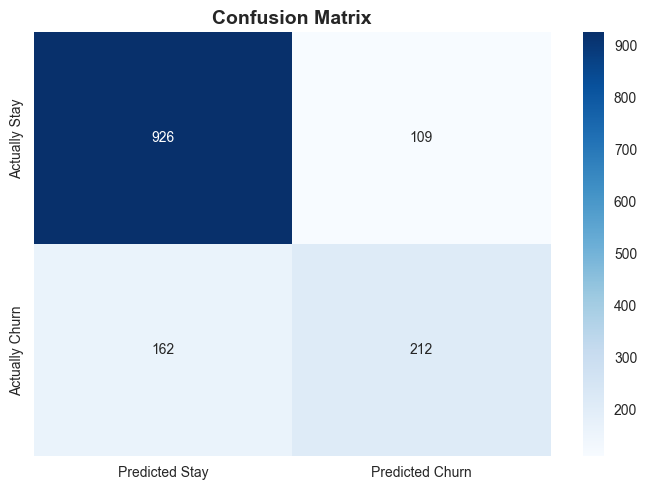


True  Negatives  (correct stay)  : 926
False Positives  (wrong churn)   : 109
False Negatives  (missed churn)  : 162
True  Positives  (correct churn) : 212


In [62]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stay','Predicted Churn'],
            yticklabels=['Actually Stay','Actually Churn'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTrue  Negatives  (correct stay)  : {cm[0][0]}")
print(f"False Positives  (wrong churn)   : {cm[0][1]}")
print(f"False Negatives  (missed churn)  : {cm[1][0]}")
print(f"True  Positives  (correct churn) : {cm[1][1]}")

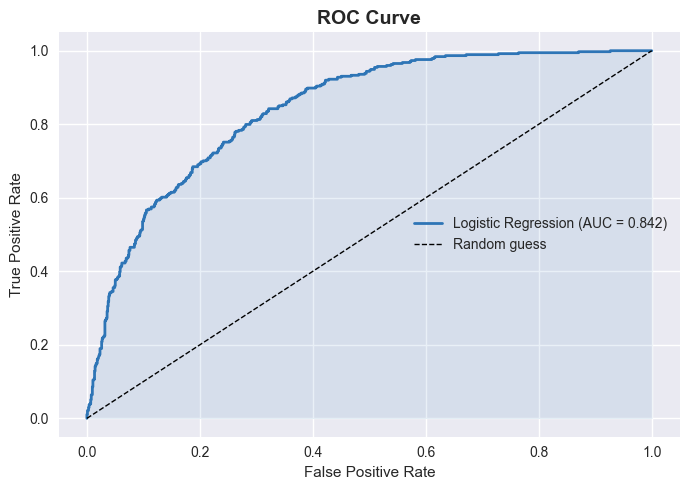

In [63]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='#2E75B6', linewidth=2,
         label=f'Logistic Regression (AUC = {roc_score:.3f})')
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random guess')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# Feature importance shows which columns affect churn the most
# Positive value = increases churn
# Negative value = decreases churn

feature_names = X.columns.tolist()
coefficients  = model.coef_[0]

# Create a dataframe of features and their importance
feat_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print("Top 10 factors that INCREASE churn:")
print(feat_df.head(10).to_string(index=False))
print("\nTop 5 factors that DECREASE churn:")
print(feat_df.tail(5).to_string(index=False))

Top 10 factors that INCREASE churn:
                       Feature  Coefficient
   InternetService_Fiber optic     0.750332
                  TotalCharges     0.494405
               StreamingMovies     0.247939
                   StreamingTV     0.246969
                 MultipleLines     0.211360
              PaperlessBilling     0.182669
PaymentMethod_Electronic check     0.181548
                 SeniorCitizen     0.053379
              DeviceProtection     0.048297
    PaymentMethod_Mailed check     0.032875

Top 5 factors that DECREASE churn:
           Feature  Coefficient
 Contract_One year    -0.283911
 Contract_Two year    -0.586568
InternetService_No    -0.625322
    MonthlyCharges    -0.851185
            tenure    -1.220126


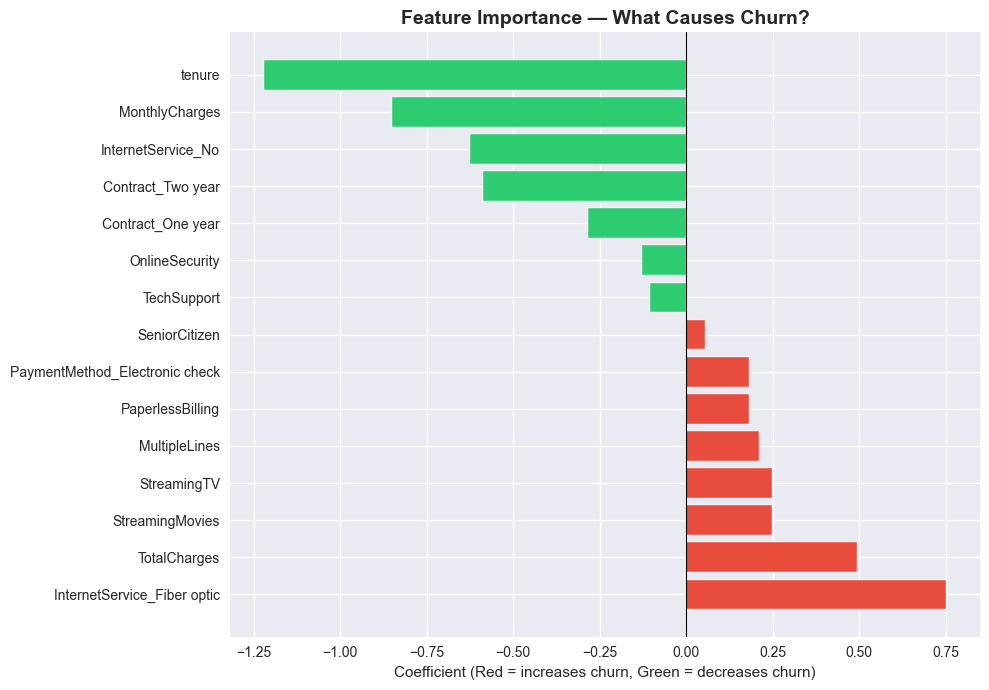

In [65]:
# Visualise top 15 most important features

top_features = pd.concat([feat_df.head(8), feat_df.tail(7)])

colors = ['#e74c3c' if c > 0 else '#2ecc71'
          for c in top_features['Coefficient']]

plt.figure(figsize=(10,7))
plt.barh(top_features['Feature'],
         top_features['Coefficient'],
         color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Importance — What Causes Churn?',
          fontsize=14, fontweight='bold')
plt.xlabel('Coefficient (Red = increases churn, Green = decreases churn)')
plt.tight_layout()
plt.show()

Contract related columns: ['Contract_One year', 'Contract_Two year']


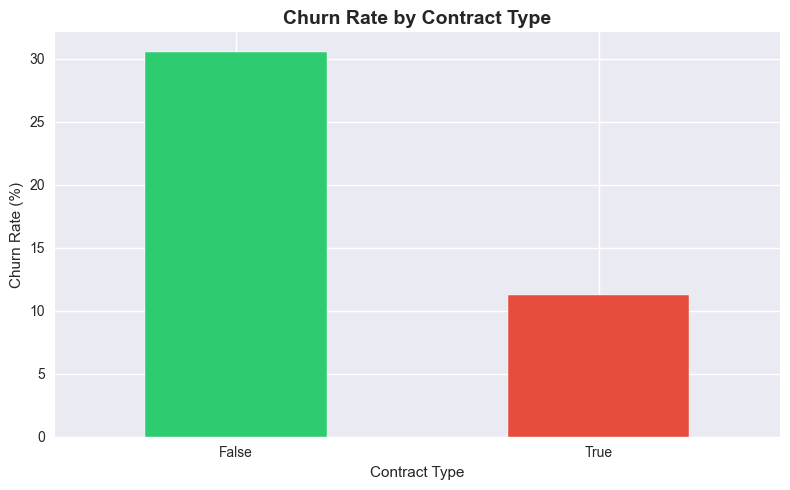

In [66]:
# Contract type is one of the strongest churn predictors

contract_cols = [col for col in df.columns if 'Contract' in col]
print("Contract related columns:", contract_cols)

plt.figure(figsize=(8,5))
churn_by_contract = df.groupby(
    [col for col in df.columns if 'Contract' in col][0]
)['Churn'].mean() * 100

churn_by_contract.plot(kind='bar',
                        color=['#2ecc71','#e74c3c'],
                        edgecolor='white',
                        figsize=(8,5))
plt.title('Churn Rate by Contract Type',
          fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [67]:
# Add churn probability to original test data
# This tells us HOW LIKELY each customer is to churn

test_results = X_test.copy()
test_results['Actual_Churn']    = y_test.values
test_results['Churn_Probability'] = y_pred_proba
test_results['Predicted_Churn'] = y_pred

# Categorise risk level
def risk_level(prob):
    if prob >= 0.7:   return '🔴 High Risk'
    elif prob >= 0.4: return '🟡 Medium Risk'
    else:             return '🟢 Low Risk'

test_results['Risk_Level'] = test_results['Churn_Probability'].apply(risk_level)

# Count by risk level
print("Customer Risk Distribution:")
print(test_results['Risk_Level'].value_counts())

print(f"\nHigh risk customers   : {(test_results['Risk_Level']=='🔴 High Risk').sum()}")
print(f"Medium risk customers : {(test_results['Risk_Level']=='🟡 Medium Risk').sum()}")
print(f"Low risk customers    : {(test_results['Risk_Level']=='🟢 Low Risk').sum()}")

Customer Risk Distribution:
Risk_Level
🟢 Low Risk       969
🟡 Medium Risk    350
🔴 High Risk       90
Name: count, dtype: int64

High risk customers   : 90
Medium risk customers : 350
Low risk customers    : 969


In [68]:
# Export results to Excel for business use

output = test_results[['Actual_Churn',
                         'Churn_Probability',
                         'Predicted_Churn',
                         'Risk_Level']].copy()

output['Churn_Probability'] = (output['Churn_Probability']*100).round(1)
output.columns = ['Actual Churn','Churn Probability %',
                   'Predicted Churn','Risk Level']

output.to_excel('../data/processed/churn_predictions.xlsx', index=False)
print("✅ Predictions saved → data/processed/churn_predictions.xlsx")
print(f"   Total customers : {len(output):,}")
print(f"   High risk       : {(output['Risk Level']=='🔴 High Risk').sum()}")

✅ Predictions saved → data/processed/churn_predictions.xlsx
   Total customers : 1,409
   High risk       : 90
